In [1]:
import sys
import os

# 1. Add the build folder to Python's search path
sys.path.append(os.path.abspath("build"))

In [2]:
import specbridge as sb

In [3]:
n_clusters = 4

In [4]:
from sklearn.datasets import make_moons, make_circles
from sklearn.datasets import make_blobs
import numpy as np

In [5]:
# Dataset 1: Moons
X_moons, y_moons = make_moons(n_samples=200, noise=0.05, random_state=42)
X_moons = X_moons.astype(np.float32)

# Dataset 2: Circles
X_circles, y_circles = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)
X_circles = X_circles.astype(np.float32)

# Dataset 3: 3 Gaussian blobs (simple, sanity check)
X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, cluster_std=0.5, random_state=42)
X_blobs = X_blobs.astype(np.float32)

# Dataset 4: larger blobs for stress test
X_large, y_large = make_blobs(n_samples=1000, centers=5, cluster_std=0.8, random_state=42)
X_large = X_large.astype(np.float32)


In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sbcluster import SpectralBridges
import matplotlib.pyplot as plt


def compare_spectral(X, y_true, name, n_clusters=2, num_voronoi=20, n_iter=20, random_state=42):
    target_perplexity = 2
    bridge = sb.SpectralClustering(
        n_clusters=n_clusters,
        num_voronoi=num_voronoi,
        n_iter=n_iter,
        target_perplexity=target_perplexity,
        random_state=random_state,
        use_gpu=False,  # Set to True to test GPU affinity computation
    )
    result = bridge.fit(X)
    labels_bindings = np.asarray(result.labels)

    author = SpectralBridges(
        n_clusters=n_clusters,
        n_nodes=num_voronoi,
        n_iter=n_iter,
        random_state=random_state,
        perplexity=target_perplexity,
    )
    labels_author = author.fit_predict(X)

    print(f"=== {name} ===")
    print("Bindings unique:", np.unique(labels_bindings))
    print("Author unique:", np.unique(labels_author))
    print("Bindings vs author ARI:", adjusted_rand_score(labels_bindings, labels_author))
    print("Bindings vs truth ARI:", adjusted_rand_score(y_true, labels_bindings))
    print("Author vs truth ARI:", adjusted_rand_score(y_true, labels_author))
    print("Bindings vs truth NMI:", normalized_mutual_info_score(y_true, labels_bindings))
    print("Author vs truth NMI:", normalized_mutual_info_score(y_true, labels_author))
    print("Bindings counts:", np.bincount(labels_bindings))
    print("Author counts:", np.bincount(labels_author))
    print()

    return labels_bindings, labels_author


labels_bindings_moons, labels_author_moons = compare_spectral(
    X_moons,
    y_moons,
    "Moons",
    n_clusters=2,
    num_voronoi=20,
)

Using GPU for affinity computation.
Computing affinity matrix on GPU... 2
=== Moons ===
Bindings unique: [0 1]
Author unique: [0 1]
Bindings vs author ARI: 1.0
Bindings vs truth ARI: 1.0
Author vs truth ARI: 1.0
Bindings vs truth NMI: 1.0
Author vs truth NMI: 1.0
Bindings counts: [100 100]
Author counts: [100 100]



In [7]:
labels_bindings_circles, labels_author_circles = compare_spectral(
    X_circles,
    y_circles,
    "Circles",
    n_clusters=2,
    num_voronoi=20,
)

Using GPU for affinity computation.
Computing affinity matrix on GPU... 2
=== Circles ===
Bindings unique: [0 1]
Author unique: [0 1]
Bindings vs author ARI: 1.0
Bindings vs truth ARI: 1.0
Author vs truth ARI: 1.0
Bindings vs truth NMI: 1.0
Author vs truth NMI: 1.0
Bindings counts: [100 100]
Author counts: [100 100]



In [8]:
labels_bindings_blobs, labels_author_blobs = compare_spectral(
    X_blobs,
    y_blobs,
    "Blobs",
    n_clusters=3,
    num_voronoi=30,
)

Using GPU for affinity computation.
Computing affinity matrix on GPU... 2
=== Blobs ===
Bindings unique: [0 1 2]
Author unique: [0 1 2]
Bindings vs author ARI: 1.0
Bindings vs truth ARI: 1.0
Author vs truth ARI: 1.0
Bindings vs truth NMI: 1.0
Author vs truth NMI: 1.0
Bindings counts: [100 100 100]
Author counts: [100 100 100]



In [9]:
labels_bindings_large, labels_author_large = compare_spectral(
    X_large,
    y_large,
    "Large",
    n_clusters=5,
    num_voronoi=50,
)

Using GPU for affinity computation.
Computing affinity matrix on GPU... 2
=== Large ===
Bindings unique: [0 1 2 3 4]
Author unique: [0 1 2 3 4]
Bindings vs author ARI: 0.9568180883296334
Bindings vs truth ARI: 0.9660170096465815
Author vs truth ARI: 0.9755329214931387
Bindings vs truth NMI: 0.9625506875447563
Author vs truth NMI: 0.9731804655667851
Bindings counts: [200 208 200 201 191]
Author counts: [208 200 200 200 192]



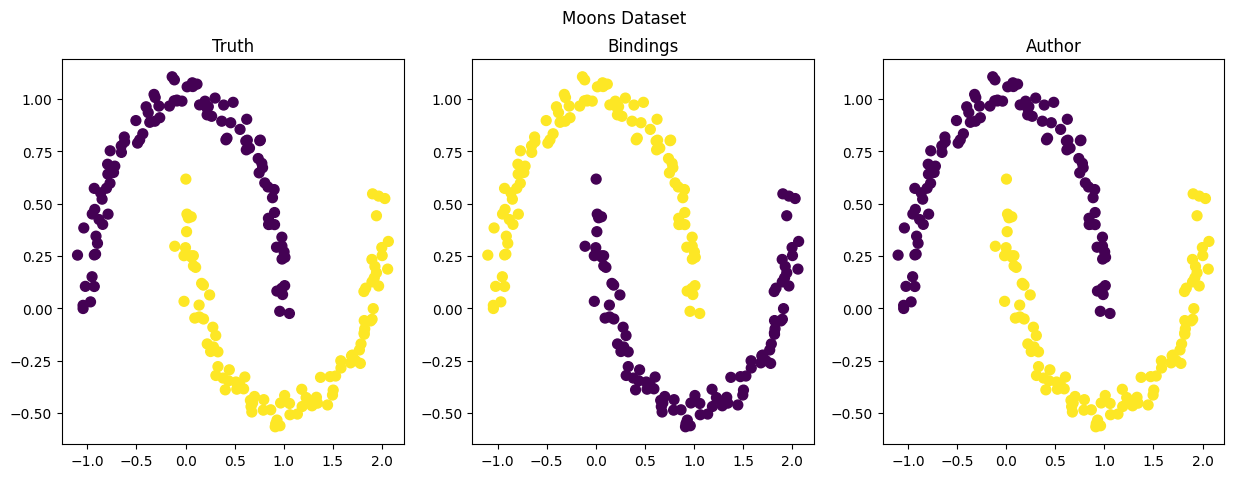

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', s=50)
axes[0].set_title('Truth')
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_bindings_moons, cmap='viridis', s=50)
axes[1].set_title('Bindings')
axes[2].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_author_moons, cmap='viridis', s=50)
axes[2].set_title('Author')
plt.suptitle('Moons Dataset')
plt.show()

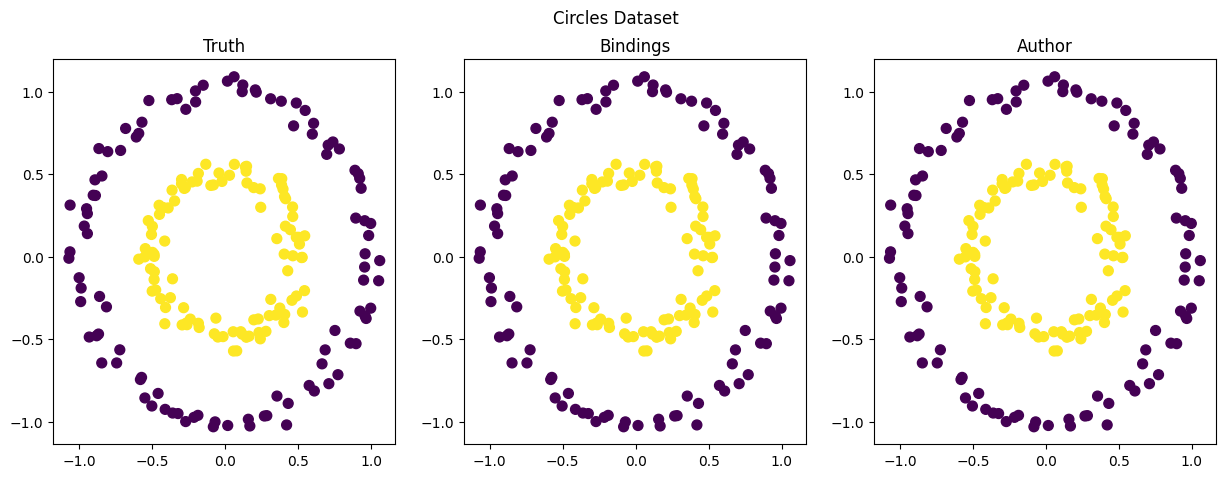

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='viridis', s=50)
axes[0].set_title('Truth')
axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=labels_bindings_circles, cmap='viridis', s=50)
axes[1].set_title('Bindings')
axes[2].scatter(X_circles[:, 0], X_circles[:, 1], c=labels_author_circles, cmap='viridis', s=50)
axes[2].set_title('Author')
plt.suptitle('Circles Dataset')
plt.show()

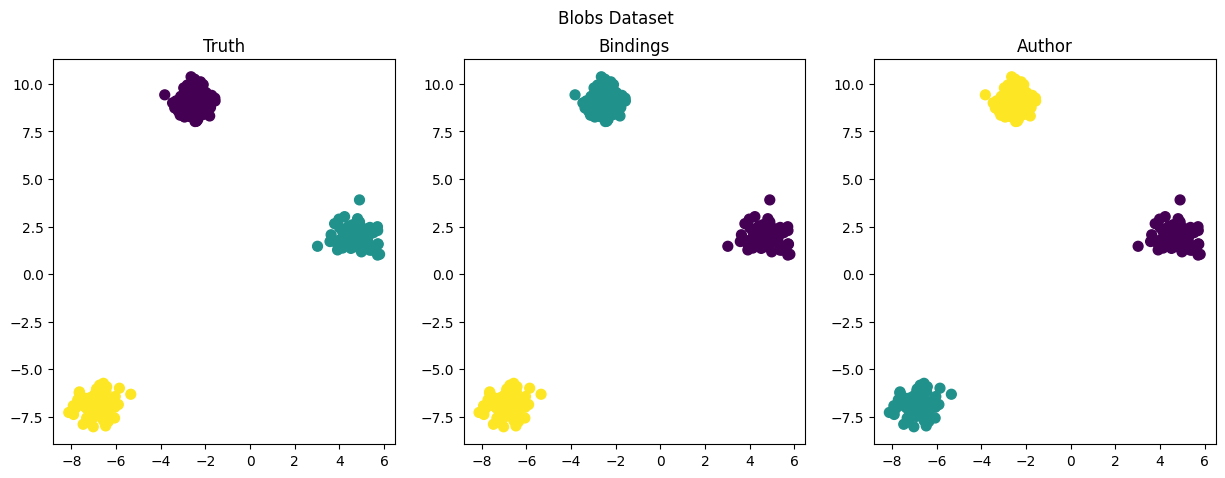

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='viridis', s=50)
axes[0].set_title('Truth')
axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_bindings_blobs, cmap='viridis', s=50)
axes[1].set_title('Bindings')
axes[2].scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_author_blobs, cmap='viridis', s=50)
axes[2].set_title('Author')
plt.suptitle('Blobs Dataset')
plt.show()

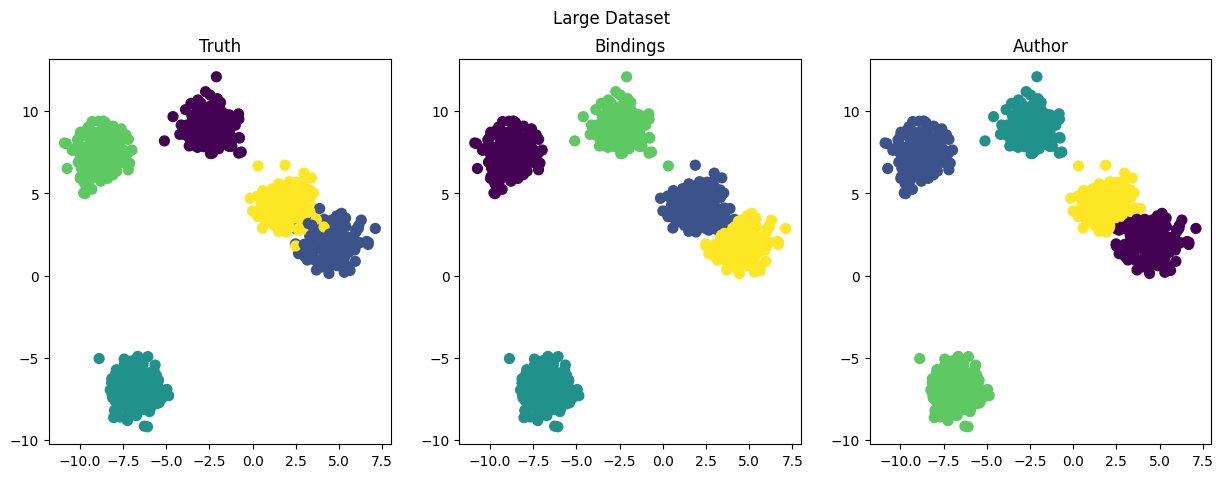

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(X_large[:, 0], X_large[:, 1], c=y_large, cmap='viridis', s=50)
axes[0].set_title('Truth')
axes[1].scatter(X_large[:, 0], X_large[:, 1], c=labels_bindings_large, cmap='viridis', s=50)
axes[1].set_title('Bindings')
axes[2].scatter(X_large[:, 0], X_large[:, 1], c=labels_author_large, cmap='viridis', s=50)
axes[2].set_title('Author')
plt.suptitle('Large Dataset')
plt.show()